In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import data_processing
from data_processing import vertical_profile_plot as vpp
from importlib import reload

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [5]:
years = h2o_data['year'].values
months = h2o_data['month'].values
days = h2o_data['day'].values
hours = h2o_data['hour'].values
times = pd.to_datetime({
    'year': years,
    'month': months,
    'day': days,
    'hour': hours
})

In [21]:
bad_profile_indices = []
for i in range(0, len(times)-1):
    orbit_number = h2o_data['orbit'][i].values
    ss = h2o_data['sunset_sunrise'][i].values

    try:
        flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        vmr = h2o_data['H2O'].sel(orbit=orbit_number, sunset_sunrise=ss).values
        mask = vmr >= 0
        flag_profile = flag_profile[mask]
        vmr = vmr[mask]
        if ((flag_profile == 4) | (flag_profile == 5) | (flag_profile == 6)).any():
            bad_profile_indices.append(i)
    except KeyError:
        print(f"Skipping missing orbit/sunset_sunrise pair: orbit={orbit_number}, sunset_sunrise={ss}")
        continue


Skipping missing orbit/sunset_sunrise pair: orbit=110807.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=110955.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111363.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111430.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111444.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111445.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=111466.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112226.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112505.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112518.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112525.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=112526.0, sunset_sunrise=1.0
Skipping missing orbit/sunset_sunrise pair: orbit=11

In [22]:
print(len(bad_profile_indices))

854


63767

In [10]:
latitudes = h2o_data['latitude'].values


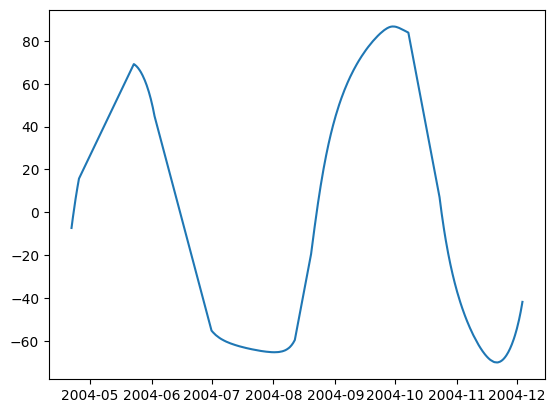

In [11]:
plt.plot(times[:1000], latitudes[:1000])

In [80]:
date_index = np.random.choice(bad_profile_indices)

<class 'numpy.int64'>
70578


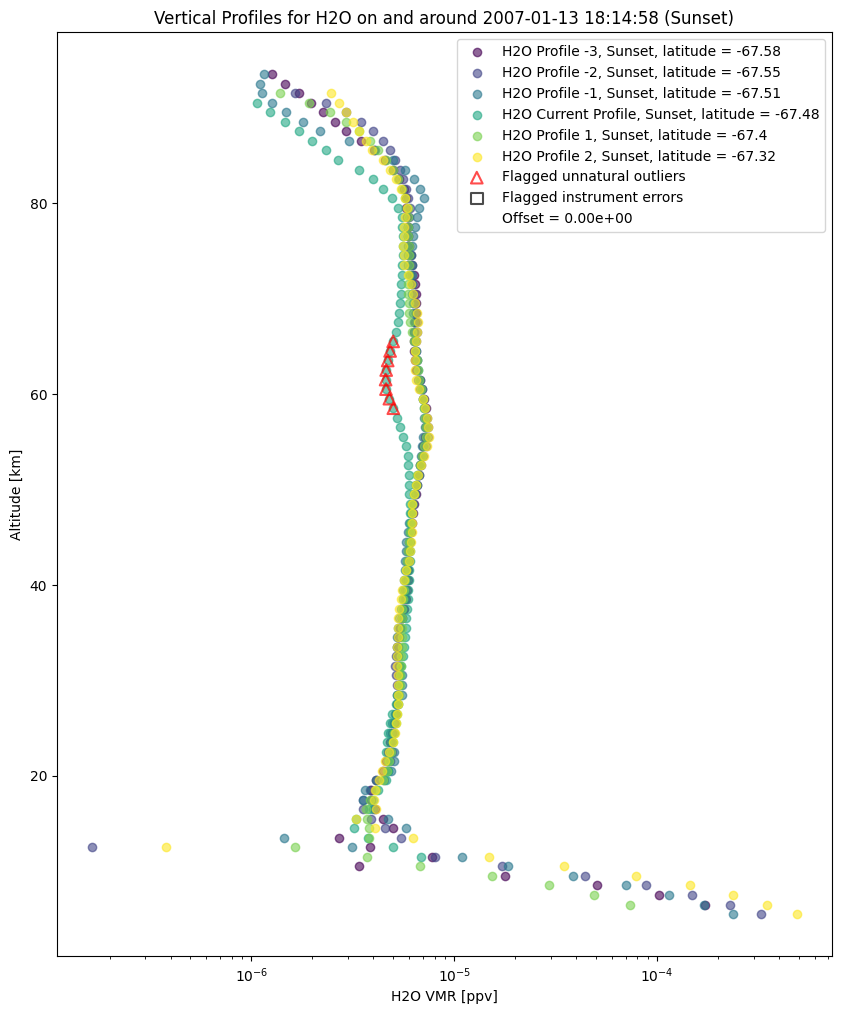

In [ ]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp
date_index = np.random.choice(bad_profile_indices)
print(date_index)
vpp('H2O', h2o_data, h2o_flags, date_index, 5)

In [ ]:
orbit = h2o_data['orbit'][date_index].values
ss = h2o_data['sunset_sunrise'][date_index].values

flag_profile = h2o_flags['quality_flag'].sel(orbit=orbit, sunset_sunrise=ss).values

In [108]:
print(times[date_index])

2023-01-14 05:10:59.009999998


In [1]:
from tabulate import tabulate

In [ ]:
years = h2o_data['year'].values

unique, counts = np.unique(years, return_counts=True)
print(tabulate(dict(zip(unique, counts)).items(), headers=["Year", "Number of samples"], tablefmt="grid"))

In [ ]:
sorted_indices = np.argsort(times.to_numpy())

sorted_years = h2o_data['year'].values[sorted_indices]

sorted_latitudes = h2o_data['latitude'].values[sorted_indices]

start_index = np.where(h2o_data['year'].values[sorted_indices] == 2017)[0][0]
end_index = np.where(h2o_data['year'].values[sorted_indices] == 2018)[0][0]

#start_index = 0
#end_index = len(sorted_latitudes)
end_index = start_index + 2760

sunset_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [0, 2]]
sunrise_latitudes = [sorted_latitudes[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

sunset_diff = np.abs(np.diff(sunset_latitudes))
sunrise_diff = np.abs(np.diff(sunrise_latitudes))

plt.figure(figsize=(10, 6))
#plt.plot(sunset_latitudes[1:len(sunset_latitudes)], sunset_diff, label = 'Sunset')
plt.plot(sunrise_latitudes[1:len(sunrise_latitudes)], sunrise_diff, label = 'Sunrise')
plt.xlabel('Latitude')
plt.ylabel('Latitude Difference between adjacent profiles')
plt.legend()
plt.show()




In [ ]:
sorted_times = times.to_numpy()[sorted_indices]

time_diff = sorted_times[end_index] - sorted_times[start_index]
print(sorted_times[start_index], sorted_times[end_index])
print(time_diff.astype('timedelta64[D]').item().days)

print((time_diff/2760).astype('timedelta64[m]'))

In [ ]:
sunrise_times = [sorted_times[i] for i in range(start_index, end_index) if h2o_data['sunset_sunrise'].values[sorted_indices[i]] in [1, 3]]

plt.plot(sunrise_times, sunrise_latitudes)
plt.xlabel('Time')
plt.ylabel('Latitude')